<a href="https://colab.research.google.com/github/annhater/M1_STAGE/blob/main/02_analysis_env25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install networkx
!pip install igraph

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt

import igraph as ig
import re
from plotly.colors import n_colors
import seaborn as sns
import numpy as np

#from igraph import Graph, Plot
#from igraph.drawing.text import TextDrawer

In [ ]:
rootdir = '/content/drive/MyDrive/M1_STAGE/Manips/Tables/'
os.chdir(rootdir)

In [ ]:
# Define the threshold for total residue interaction weight
WEIGHT_THRESHOLD = 50 # Adjust this value as needed

In [ ]:
#IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
import os
import igraph as ig
import re
#from igraph import Graph, Plot
#from igraph.drawing.text import TextDrawer

#SETUP
rootdir = "/content/drive/MyDrive/M1_STAGE/Manips/Tables"
os.chdir(rootdir)

#MAIN
# 1. Open df

freq_df_paths = ["V1_ASP_chA_env_atoms_frequency.csv",
                "V11_ASP_chA_env_atoms_frequency.csv",
                "V12_ASP_chA_env_atoms_frequency.csv",
                "V7_ASP_chA_env_atoms_frequency.csv",
                "V8_ASP_chA_env_atoms_frequency.csv",
                "V21_ASP_chA_env_atoms_frequency.csv"]
df_list = []
CA_atoms = []
residue_dico = {}
residue_identifier_set_all_sims = set()

for sim in freq_df_paths:
    # 1. Read the frequency data, save as df
    sim_name = sim.replace("_ASP_chA_env_atoms_frequency.csv", "")
    df_sim = pd.read_csv(sim)

    # 2. Filter only CA
    filtered_CA = df_sim[
        df_sim["Residue"].apply(lambda x: 'CA' in x and 'ASP_25' not in x)
        ].copy()

    # 3. Save to new df, indicate graph parameters
    df_new = pd.DataFrame()
    df_new["Source"] = filtered_CA["Residue"]
    df_new["Target"] = "CA_Asp25_chA"
    df_new["Weight"] = filtered_CA['Frequency'].apply(lambda x: int(x))

    # 4. For each CA, get their residue and chain
    chain_label_list = []
    res_id_list = []
    for CA in filtered_CA["Residue"].values:
        res_str = CA.split('_')
        atom_id = int(res_str[0])
        res_id = '_'.join(res_str[2:])
        if atom_id < 1536:
            chain_label_list.append("Chain A")
        else:
            chain_label_list.append("Chain B")
        res_id_list.append(res_id)
        # 5. Collect all unique residues in a set
        residue_identifier_set_all_sims.add(res_id)

    # 6. Add chain id and res_id to new df for graph
    df_new["Chain"] = chain_label_list
    df_new["Residue_Id"] = res_id_list

    df_list.append((sim_name, df_new))

# Make color dict for coloring the CA atoms
residue_id_color_dico = {}
for i, res_id in enumerate(sorted(list(residue_identifier_set_all_sims))):
    np.random.seed(i) # Use seed for reproducibility of colors based on index
    color = tuple(np.random.choice(range(256), size=3) / 255.0)
    residue_id_color_dico[res_id] = color

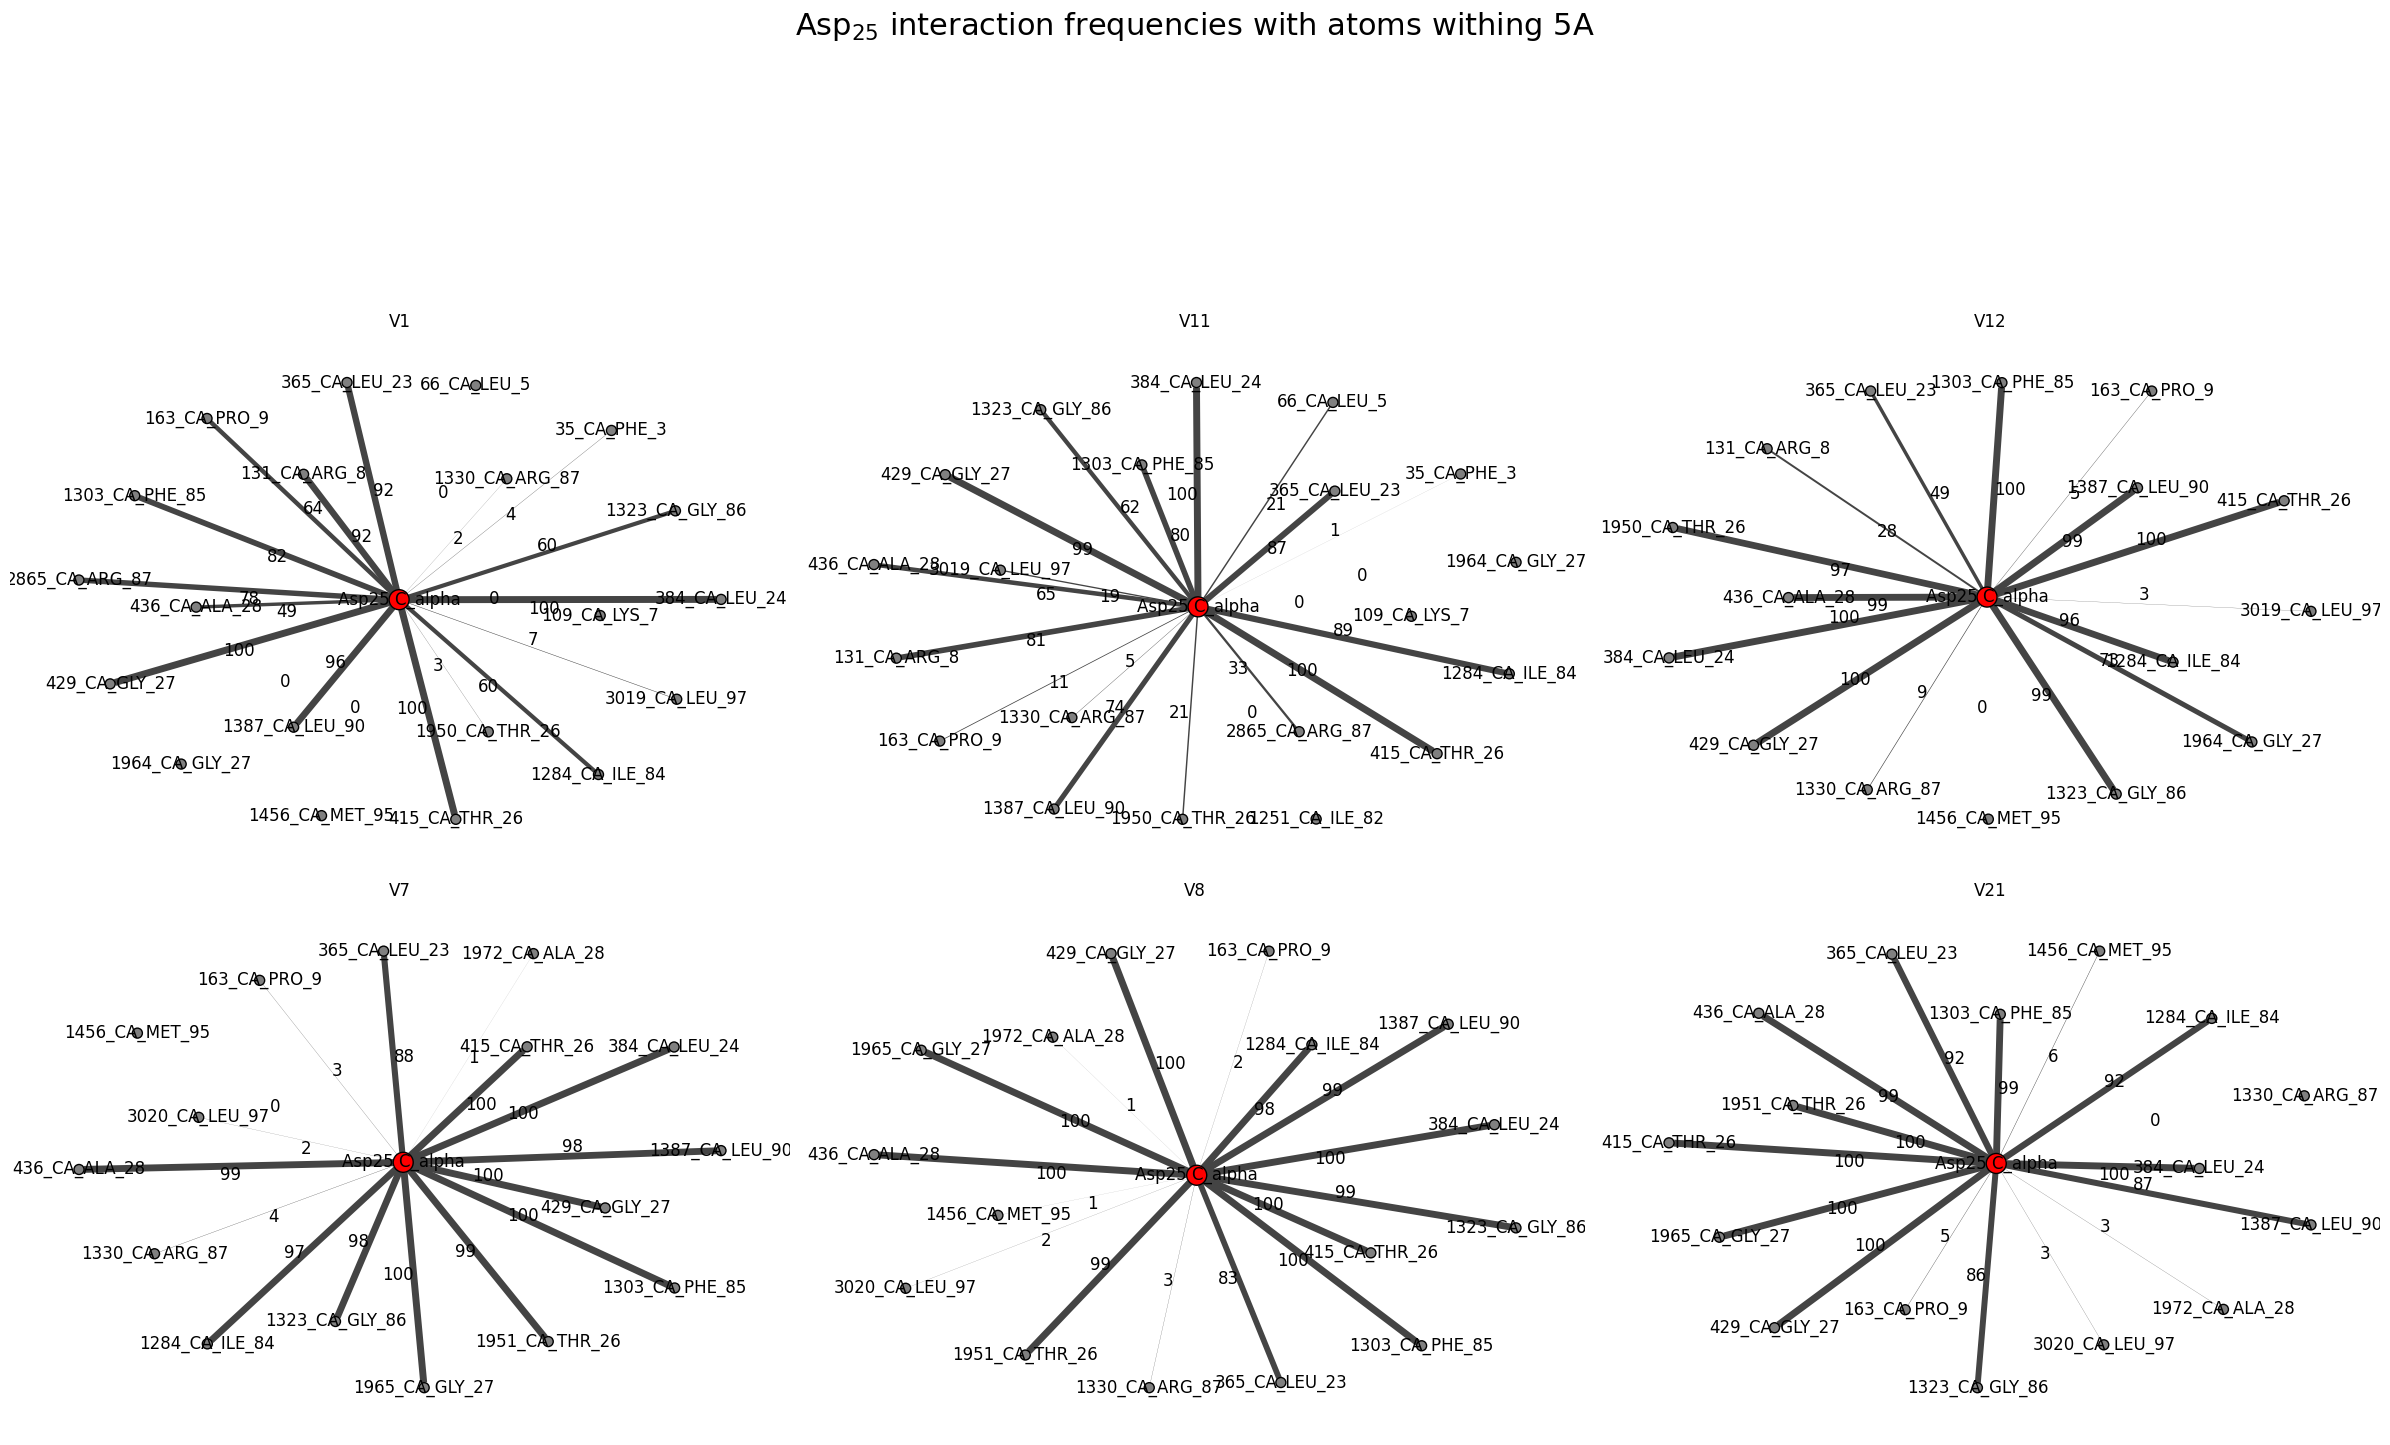

In [ ]:
color_dico = {}

residue_set = set()
for residue_list in residue_dico.values():
        for residue in residue_list:
                residue_set.add(residue)
for i, residue in enumerate(residue_set):
        color = tuple(np.random.choice(range(256), size=3) / 255.0)
        #print(residue, color)
        color_dico[residue] = color
        #color_dico = dict(zip(residue,color))
        #color_dico.get(residue, color)
color_dico #Prep for plot
num_simulations = 6
num_cols_plot = min(num_simulations, 3)
num_rows_plot = (num_simulations + num_cols_plot - 1) // num_cols_plot
color_dict = {}
fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(num_cols_plot * 8, num_rows_plot * 6), squeeze=False)
axes = axes.flatten()
plot_idx = 0
fig.suptitle("Asp$_{25}$ interaction frequencies with atoms withing 5A", fontsize=22, y=1.2)

for (sim_name, sim), ax in zip(df_list, axes):
    ax.set_title(sim_name)
    sim_df = pd.DataFrame(sim)
    g = ig.Graph.DataFrame(sim_df, directed=False, use_vids=False)
    vertices = g.vs['name']
    colors = []
    labels = []
    sizes = []
    for v in vertices:
        if v == "CA_Asp25_chA":
            colors.append((1.0, 0.0, 0.0)) # red for central
            labels.append("Asp25 C_alpha")
            sizes.append(20)
        else:
            residue = v.split('_')[-1]
            color = residue_id_color_dico.get(residue, (0.5, 0.5, 0.5))
            colors.append(color)
            labels.append(v)
            sizes.append(10)

    weights = g.es['Weight']
    edge_widths = [w/20 for w in weights]
    ig.plot(g, target=ax,
            vertex_size=sizes,
            vertex_color=colors,
            vertex_label=labels,
            edge_width=edge_widths,
            edge_label=weights,
            edge_curved=0,
            layout='fr',
            bbox=(400, 400),
            margin=20)
    plot_idx += 1

# Hide any unused subplots
for j in range(plot_idx, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

/tmp/ipykernel_7771/3284286270.py:97: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  legend_handles.append(mpatches.Patch(color=chain_colors["Chain A"], label='Chain A Group', edgecolor='black', linewidth=0.5))
/tmp/ipykernel_7771/3284286270.py:99: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  legend_handles.append(mpatches.Patch(color=chain_colors["Chain B"], label='Chain B Group', edgecolor='black', linewidth=0.5))


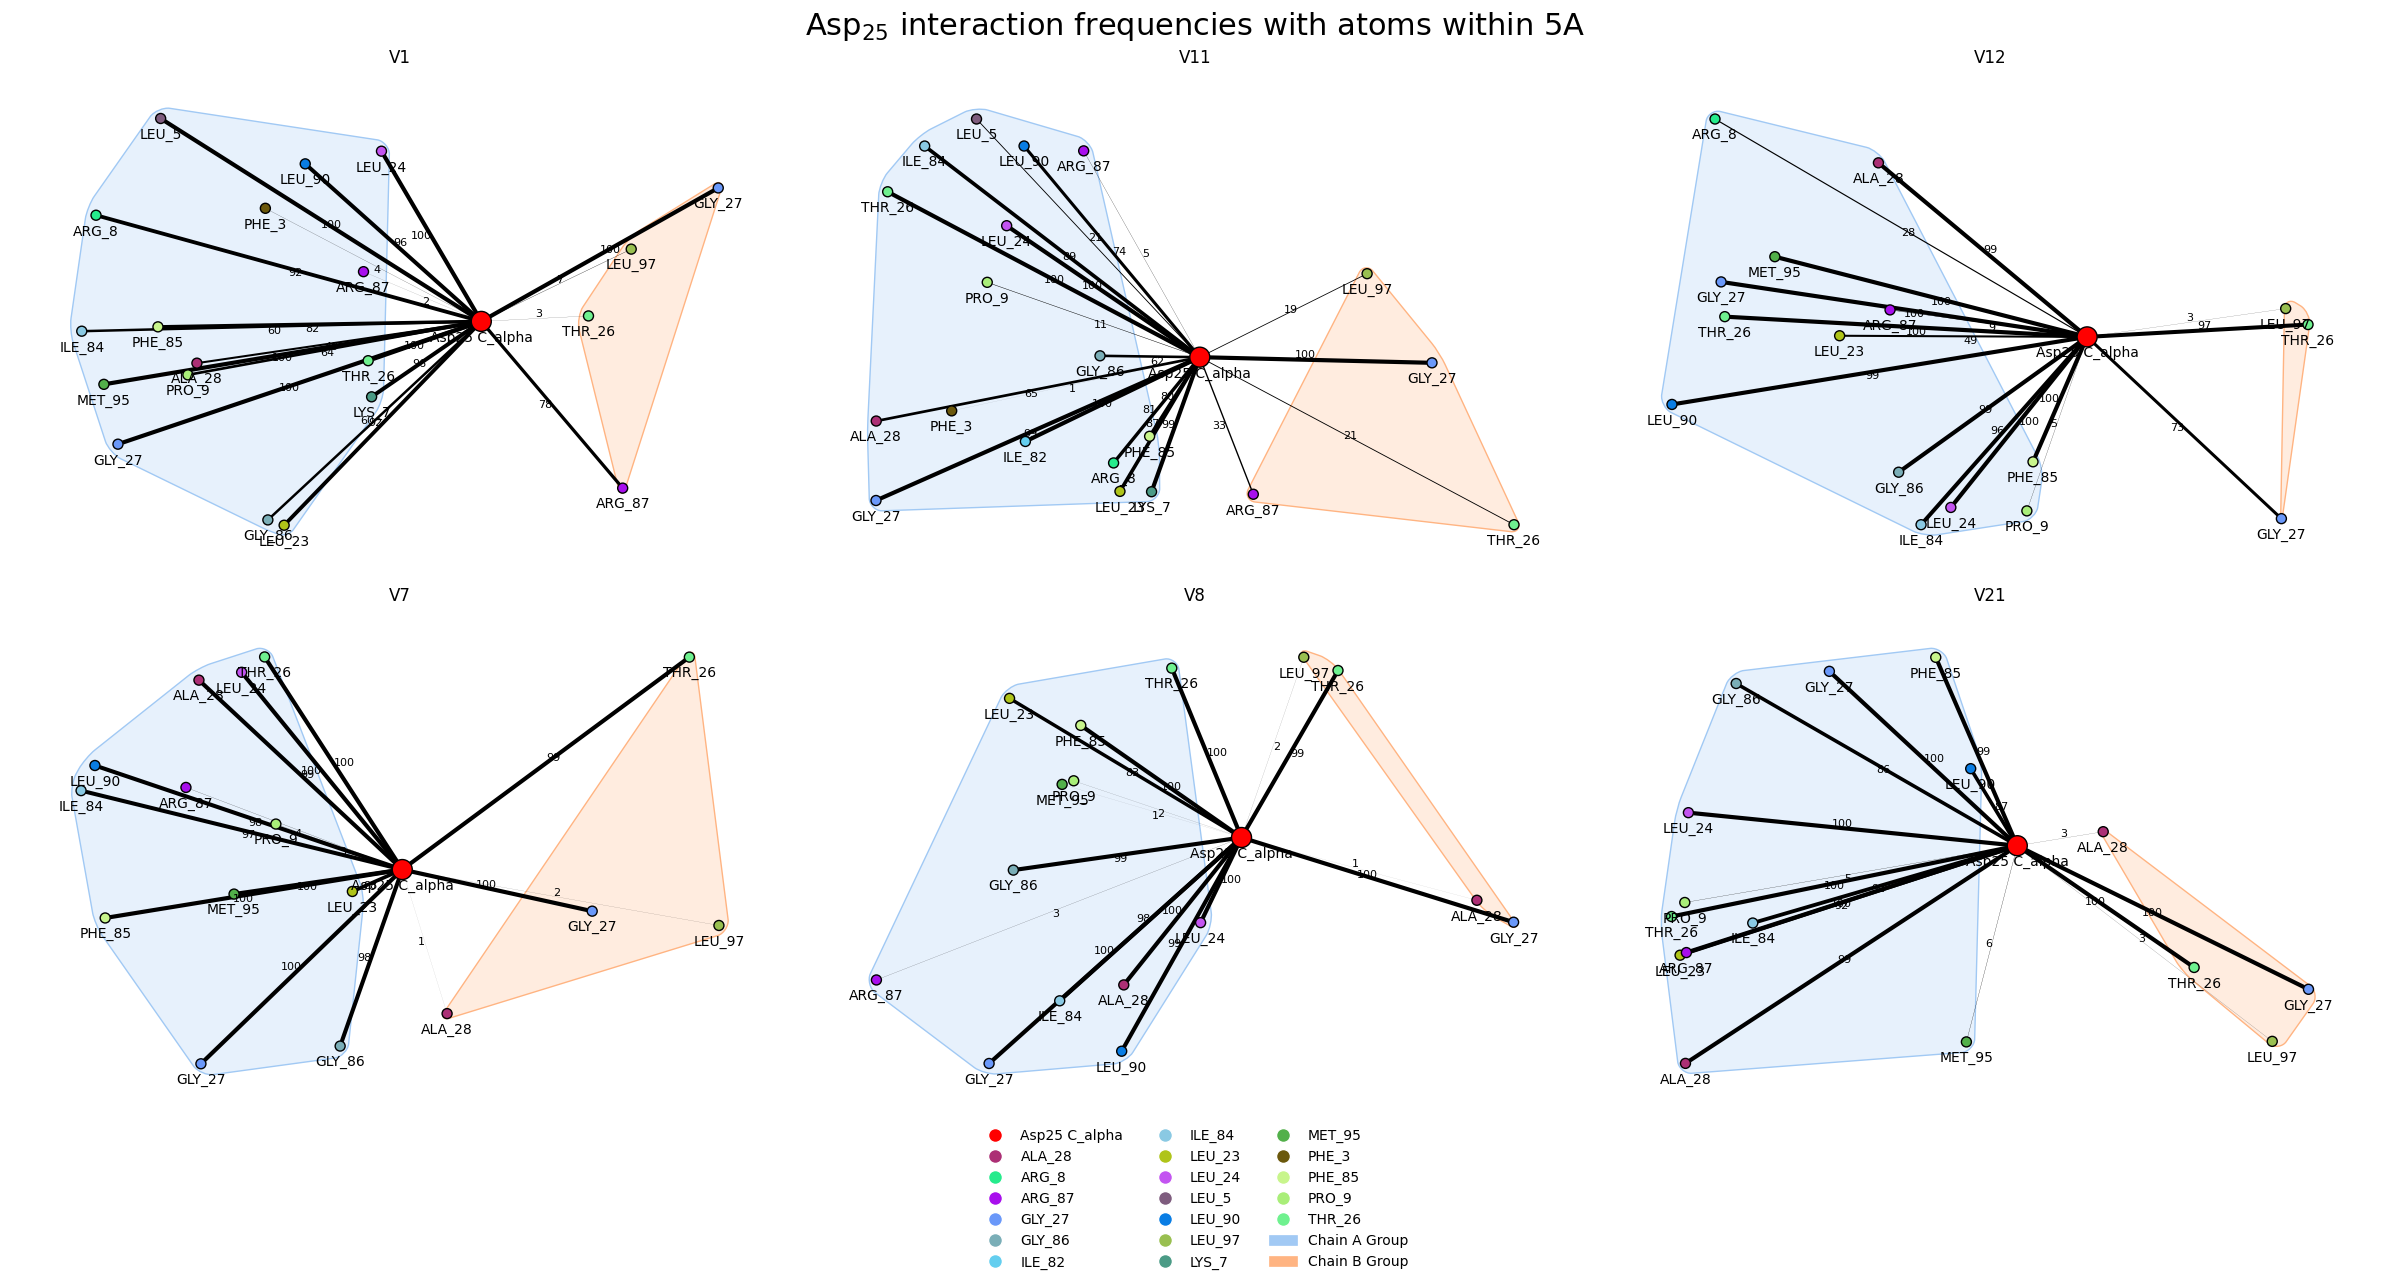

In [ ]:
chain_colors = {"Chain A": "#a1c9f4", "Chain B": "#ffb482"} # Soft Blue and Soft Orange

num_simulations = len(df_list)
num_cols_plot = 3
num_rows_plot = (num_simulations + num_cols_plot - 1) // num_cols_plot # Calculate rows needed for plots (3 for 6 sims)

fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(num_cols_plot * 8, num_rows_plot * 6), squeeze=False)
axes = axes.flatten()
fig.suptitle("Asp$_{25}$ interaction frequencies with atoms within 5A", fontsize=22)

for plot_idx, ((sim_name, sim_df_current), ax) in enumerate(zip(df_list, axes)):
    ax.set_title(sim_name)

    # Create the graph
    g = ig.Graph.DataFrame(sim_df_current, directed=False, use_vids=False)

    # Add chain and residue_identifier as vertex attributes to the graph
    source_chain_map = sim_df_current.set_index('Source')['Chain'].to_dict()
    source_res_id_map = sim_df_current.set_index('Source')['Residue_Id'].to_dict()

    for v_idx in range(len(g.vs)):
        v_name = g.vs[v_idx]['name']
        if v_name == "CA_Asp25_chA":
            g.vs[v_idx]['chain'] = 'Chain A' # Explicitly assign chain for the central atom
            g.vs[v_idx]['residue_identifier'] = 'ASP_25' # Explicitly assign residue identifier
        else:
            g.vs[v_idx]['chain'] = source_chain_map.get(v_name, 'Unknown')
            g.vs[v_idx]['residue_identifier'] = source_res_id_map.get(v_name, 'Unknown')

    vertices = g.vs
    colors = []
    labels = []
    sizes = []
    group_A_indices = []
    group_B_indices = []
    custom_layout = [] # This will store [x, y] coordinates for each vertex

    for i, v in enumerate(vertices):
        if v['name'] == "CA_Asp25_chA":
            colors.append((1.0, 0.0, 0.0)) # Red for central atom
            labels.append("\n\n"+"Asp25 C_alpha")
            sizes.append(20)
            custom_layout.append([0.0, 0.0]) # Central node at origin
        else:
            color = residue_id_color_dico.get(v['residue_identifier'], (0.5, 0.5, 0.5)) # Use global color dictionary
            colors.append(color)
            labels.append("\n\n"+v['residue_identifier'])
            sizes.append(10)
            # Assign initial layout positions based on chain
            if v['chain'] == "Chain A":
                group_A_indices.append(i)
                # Distribute Chain A nodes on the left side (negative x)
                custom_layout.append([np.random.uniform(-0.9, -0.1), np.random.uniform(-0.7, 0.7)])
            elif v['chain'] == "Chain B":
                group_B_indices.append(i)
                # Distribute Chain B nodes on the right side (positive x)
                custom_layout.append([np.random.uniform(0.1, 0.9), np.random.uniform(-0.7, 0.7)])
            else: # Fallback for any unknown chain
                custom_layout.append([np.random.uniform(-0.1, 0.1), np.random.uniform(-0.1, 0.1)]) # Place around center

    weights = [w for w in g.es['Weight'] if w>0]
    edge_widths = [(w/50)*1.5 for w in weights] # Reduced divisor for thicker lines

    ig.plot(g, target=ax,
            vertex_size=sizes,
            vertex_color=colors,
            vertex_label=labels,
            vertex_label_size=10,
            edge_width=edge_widths,
            edge_curved=0,
            edge_label=weights,
            edge_label_size=8,
            edge_color='black',
            layout=custom_layout,
            bbox=(400, 400),
            mark_groups=[(group_A_indices, chain_colors["Chain A"]),
                        (group_B_indices, chain_colors["Chain B"])],
            margin=20)

# Create legend handles and labels (this part remains largely the same)
legend_handles = []
legend_labels = []

# Add central atom
legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', label='Asp25 C_alpha',
                                markerfacecolor=(1.0, 0.0, 0.0), markersize=10))
legend_labels.append('Asp25 C_alpha')

# Add residue colors
for res_id, color in sorted(residue_id_color_dico.items()):
    legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', label=res_id,
                                    markerfacecolor=color, markersize=10))
    legend_labels.append(res_id)

# Add chain mark_groups explanation (as colored rectangles)
import matplotlib.patches as mpatches
legend_handles.append(mpatches.Patch(color=chain_colors["Chain A"], label='Chain A Group', edgecolor='black', linewidth=0.5))
legend_labels.append('Chain A Group')
legend_handles.append(mpatches.Patch(color=chain_colors["Chain B"], label='Chain B Group', edgecolor='black', linewidth=0.5))
legend_labels.append('Chain B Group')


# Place a figure-level legend instead of in a separate subplot
fig.legend(handles=legend_handles, labels=legend_labels,
           loc='lower center', ncol=3, fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout(rect=[0, 0.05, 1, 1]) # Adjust tight_layout to make space for the legend at the bottom
plt.show()
fig.savefig("../Figures/Env25_graph")